# **Clasificación de Emociones Caninas con InceptionV3**
### Trabajo Práctico Final IIA - Opción 4: Fine-Tuning
#### Santiago Bussanich, Tomás Castagnino, Gaspar Giménez

**Objetivo:** Desarrollar un sistema capaz de clasificar el estado emocional de un perro
a partir de imágenes utilizando Transfer Learning y Fine-Tuning sobre la arquitectura de InceptionV3.

**Motivación**
* Aprovechar modelos preentrenados para tareas de visión por computadora.
* Analizar la capacidad de adaptación de InceptionV3 a un dominio específico.
* Construir una aplicación sencilla que permita monitorear el estado emocional de una mascota mediante una cámara.

**Resultado esperado**: Clasificación automática de emociones caninas en tiempo real.

[Data set elegido](https://www.kaggle.com/datasets/danielshanbalico/dog-emotion)


Usaremos [esta](https://www.kaggle.com/code/yasserh/inception-v3-implementation) guía de implementación para el uso de InceptionV3.

Dos detalles a notar de InceptionV3:

| Detalle           | Valor                           | Por qué                                                                                                                          |
| ----------------- | ------------------------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| Tamaño de entrada | 299×299 px                      | InceptionV3 fue diseñada para ese tamaño (otras redes usan 224).                                                                 |
| Preprocesado      | `inception_v3.preprocess_input` | Escala los píxeles al rango `[-1, 1]`, que es como la red vio ImageNet. Si le pasás `[0,255]` o `[0,1]`, predice cualquier cosa. |

Links útiles que vamos anotando:


*   [Keras documentation](https://keras.io/api/utils/)
    1.   En particular, [carga de imágenes](https://keras.io/api/data_loading/image/)
    2.   [Ejemplo de uso Keras para clasificación de imágenes](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
    3.   [Guía de Keras para transfer learning (AUTOTUNE)](https://keras.io/guides/transfer_learning/): ejemplo de

    ```python
    train_ds = train_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    validation_ds = validation_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    test_ds = test_ds.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    ```

    4. [InceptionV3 con Keras](https://keras.io/api/applications/inceptionv3/)

    5. [Prepocesamiento con Incpetion](https://keras.io/api/applications/inceptionv3/inception_v3_preprocessing/): en particular vamos a usar la funcion preprocess_input que escala a [-1,1] un input x.



*   [Repo Github](https://github.com/gaspigz/TP-FINAL-IIA)


# **Sección 1: Set Up general**

En esta parte installamos las librerias que necesitamos en el Sistema Operativo e importamos todas las librerias de Python que vamos a usar.

In [43]:
!pip install tensorflow==2.21.0 keras==3.15.0 kagglehub==1.0.2 pandas==3.0.3 numpy==2.5.0 pillow==12.2.0 scikit-learn==1.9.0 matplotlib==3.11.0 seaborn==0.13.2 opencv-python==4.13.0.92

/bin/bash: line 1: pip: command not found


In [44]:
# Imports
import os
import keras
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.inception_v3 import preprocess_input

from keras import layers


In [45]:
import sys, tensorflow as tf
print("python:", sys.executable)
print("GPU:", tf.config.list_physical_devices("GPU"))

python: /home/bussa/venvs/tp-final/bin/python
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Sección 2: Dataset**

Importamos el dataset de Kaggle, verificamos que lo hayamos descargado bien y despues normalizamos el dataset para poder usarlo con InnceptionV3.

Cuando quisimos procesar el dataset como veniamos haciendo en los tp anteriores (en forma de array) nos paso que google colab se nos quedaba sin RAM porque ahora las fotos son de 299x299x3, a diferencia de CIFAR10 que eran 32x32x3. Asi que trabajamos las imagenes con funciones la funcion shuffel para "mezclar" las imagenes y con .take y .skip para separar el dataset.

In [46]:
# Credenciales de Kaggle + descarga del dataset.
# Funciona en Google Colab y en local sin cambios: detecta el entorno automaticamente.
try:
    # las credenciales se leen desde los secrets de colab
    # Hay que cargar dos secrets: KAGGLE_USERNAME y KAGGLE_KEY.
    from google.colab import userdata
    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Entorno detectado: Google Colab (credenciales desde Secrets)")
except ImportError:
    # Local: leer kaggle.json desde la raiz del proyecto (junto a requirements.txt)
    # El archivo esta ignorado por git (.gitignore)
    import json
    cred_path = os.path.join(os.getcwd(), "kaggle.json")
    with open(cred_path) as f:
        creds = json.load(f)
    os.environ["KAGGLE_USERNAME"] = creds["username"]
    os.environ["KAGGLE_KEY"] = creds["key"]
    print(f"Entorno detectado: local (credenciales desde {cred_path})")

path = kagglehub.dataset_download("danielshanbalico/dog-emotion")
print("Dataset en:", path)

Entorno detectado: local (credenciales desde /mnt/c/Users/santi/OneDrive/Desktop/IIA/TP-FINAL-IIA/kaggle.json)
Dataset en: /home/bussa/.cache/kagglehub/datasets/danielshanbalico/dog-emotion/versions/1


In [47]:
# Explroemos la estructura de archivos
# Sirve para poder verificar que estan los archivos cargados
for root, dirs, files in os.walk(path):
    nivel = root.replace(path, "").count(os.sep)
    print("  " * nivel, os.path.basename(root), f"({len(files)} archivos)")
    for f in files[:2]:
        print("  " * (nivel + 1), "•", f)

 1 (0 archivos)
   Dog Emotion (1 archivos)
     • labels.csv
     relaxed (1000 archivos)
       • puRQ2KTxMSS7AVljWhFc4nxjgkXu1m716.jpg
       • 5iT5Z74uGphUjW9OGzPyCVVcqjL4fL265.jpg
     sad (1000 archivos)
       • wdyRbR46ZzQXLBXuJx59GDVvTZNjIS883.jpg
       • sdlB1uI11LeGPM7YDi9KOoH8FjXjyG914.jpg
     angry (1000 archivos)
       • 0jgI6KwR6IGvq9CAMBB3srLRa0W7z7192.jpg
       • QAapmNL7cp1EKtX8cITSKO08is9vk7527.jpg
     happy (1000 archivos)
       • CIwfTzIrrWfd3Rv9RJnvVlJXFCVpiA100.jpg
       • Tc9jVzd89hkETHoWPSu9KiLYGKh6hK395.jpg


In [48]:
# Leer y mostrar el archivo CSV
csv_path = os.path.join(path, "Dog Emotion", "labels.csv")
df = pd.read_csv(csv_path)

# Mostrar las primeras filas del DataFrame
df.head()

,Unnamed: 0,filename,label
0,0,yubL63eiiPmoRru8Z2K2yRo0NnGDCL683.jpg,sad
1,1,c1tVljKiLM9q2zTBuQGWpxmzBuSeBR437.jpg,sad
2,2,RbzNOvY5GIAl3PSjIRTKpEkQs1NByq575.jpg,angry
3,3,gKujaBuWYezz0yWK9ydTFVi6LbQtXe397.jpg,angry
4,4,U0hJ2ryOu1IOuYpc01O7RngPYa8Xvz795.jpg,relaxed


In [49]:
import pathlib
from sklearn.model_selection import train_test_split

IMG_SIZE = (299, 299)   # InceptionV3 espera 299x299
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

data_dir = os.path.join(path, "Dog Emotion")

class_names = {0: "angry", 1: "happy", 2: "relaxed", 3: "sad"}
num_classes = len(class_names)
CLASES = [class_names[i] for i in range(num_classes)]   # orden alfabético = carpetas

# --- Split determinista y estratificado sobre la LISTA DE ARCHIVOS ----------------
# Hacer el split sobre los archivos (y NO sobre un dataset ya decodificado) evita
# re-decodificar las 4000 imágenes en cada época, que era lo que volvía todo lentísimo.
def _listar_archivos(data_dir, clases=CLASES):
    paths, labels = [], []
    for idx, cls in enumerate(clases):
        for f in sorted(pathlib.Path(data_dir, cls).glob("*")):
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                paths.append(str(f)); labels.append(idx)
    return np.array(paths), np.array(labels)

paths_all, labels_all = _listar_archivos(data_dir)

# 60% train / 20% val / 20% test, manteniendo el balance de clases
p_tmp, p_test, y_tmp, y_test = train_test_split(
    paths_all, labels_all, test_size=0.20, stratify=labels_all, random_state=SEED)
p_train, p_val, y_train, y_val = train_test_split(
    p_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=SEED)   # 0.25*0.8 = 0.2

# --- Carga + preprocesado, con CACHE en disco ANTES del shuffle/batch -------------
def _cargar(p, y):
    img = tf.io.read_file(p)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)          # InceptionV3: [-1, 1]
    return img, y

def _arma_ds(paths, labels, cache_file, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        # mezcla el ORDEN DE ARCHIVOS una sola vez (barato: son strings, sin decodificar)
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=False)
    ds = ds.map(_cargar, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(cache_file)            # se llena UNA vez (1ra época) y se reusa
    if shuffle:
        # variación por época con poca RAM (~0.5 GB de buffer, no las 4000 imágenes)
        ds = ds.shuffle(512, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = _arma_ds(p_train, y_train, "/tmp/tp_train", shuffle=True)
val_ds   = _arma_ds(p_val,   y_val,   "/tmp/tp_val")
test_ds  = _arma_ds(p_test,  y_test,  "/tmp/tp_test")

print("Clases:", CLASES)
print(f"train: {len(p_train)} | val: {len(p_val)} | test: {len(p_test)} imágenes")

Clases: ['angry', 'happy', 'relaxed', 'sad']
train: 2400 | val: 800 | test: 800 imágenes


I0000 00:00:1782686491.908463   66124 shuffle_dataset_op.cc:453] ShuffleDatasetV3:85: Filling up shuffle buffer (this may take a while): 321 of 512
I0000 00:00:1782686499.779431   66124 shuffle_dataset_op.cc:483] Shuffle buffer filled.
W0000 00:00:1782686500.958854   45992 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 34330240 bytes after encountering the first element of size 34330240 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


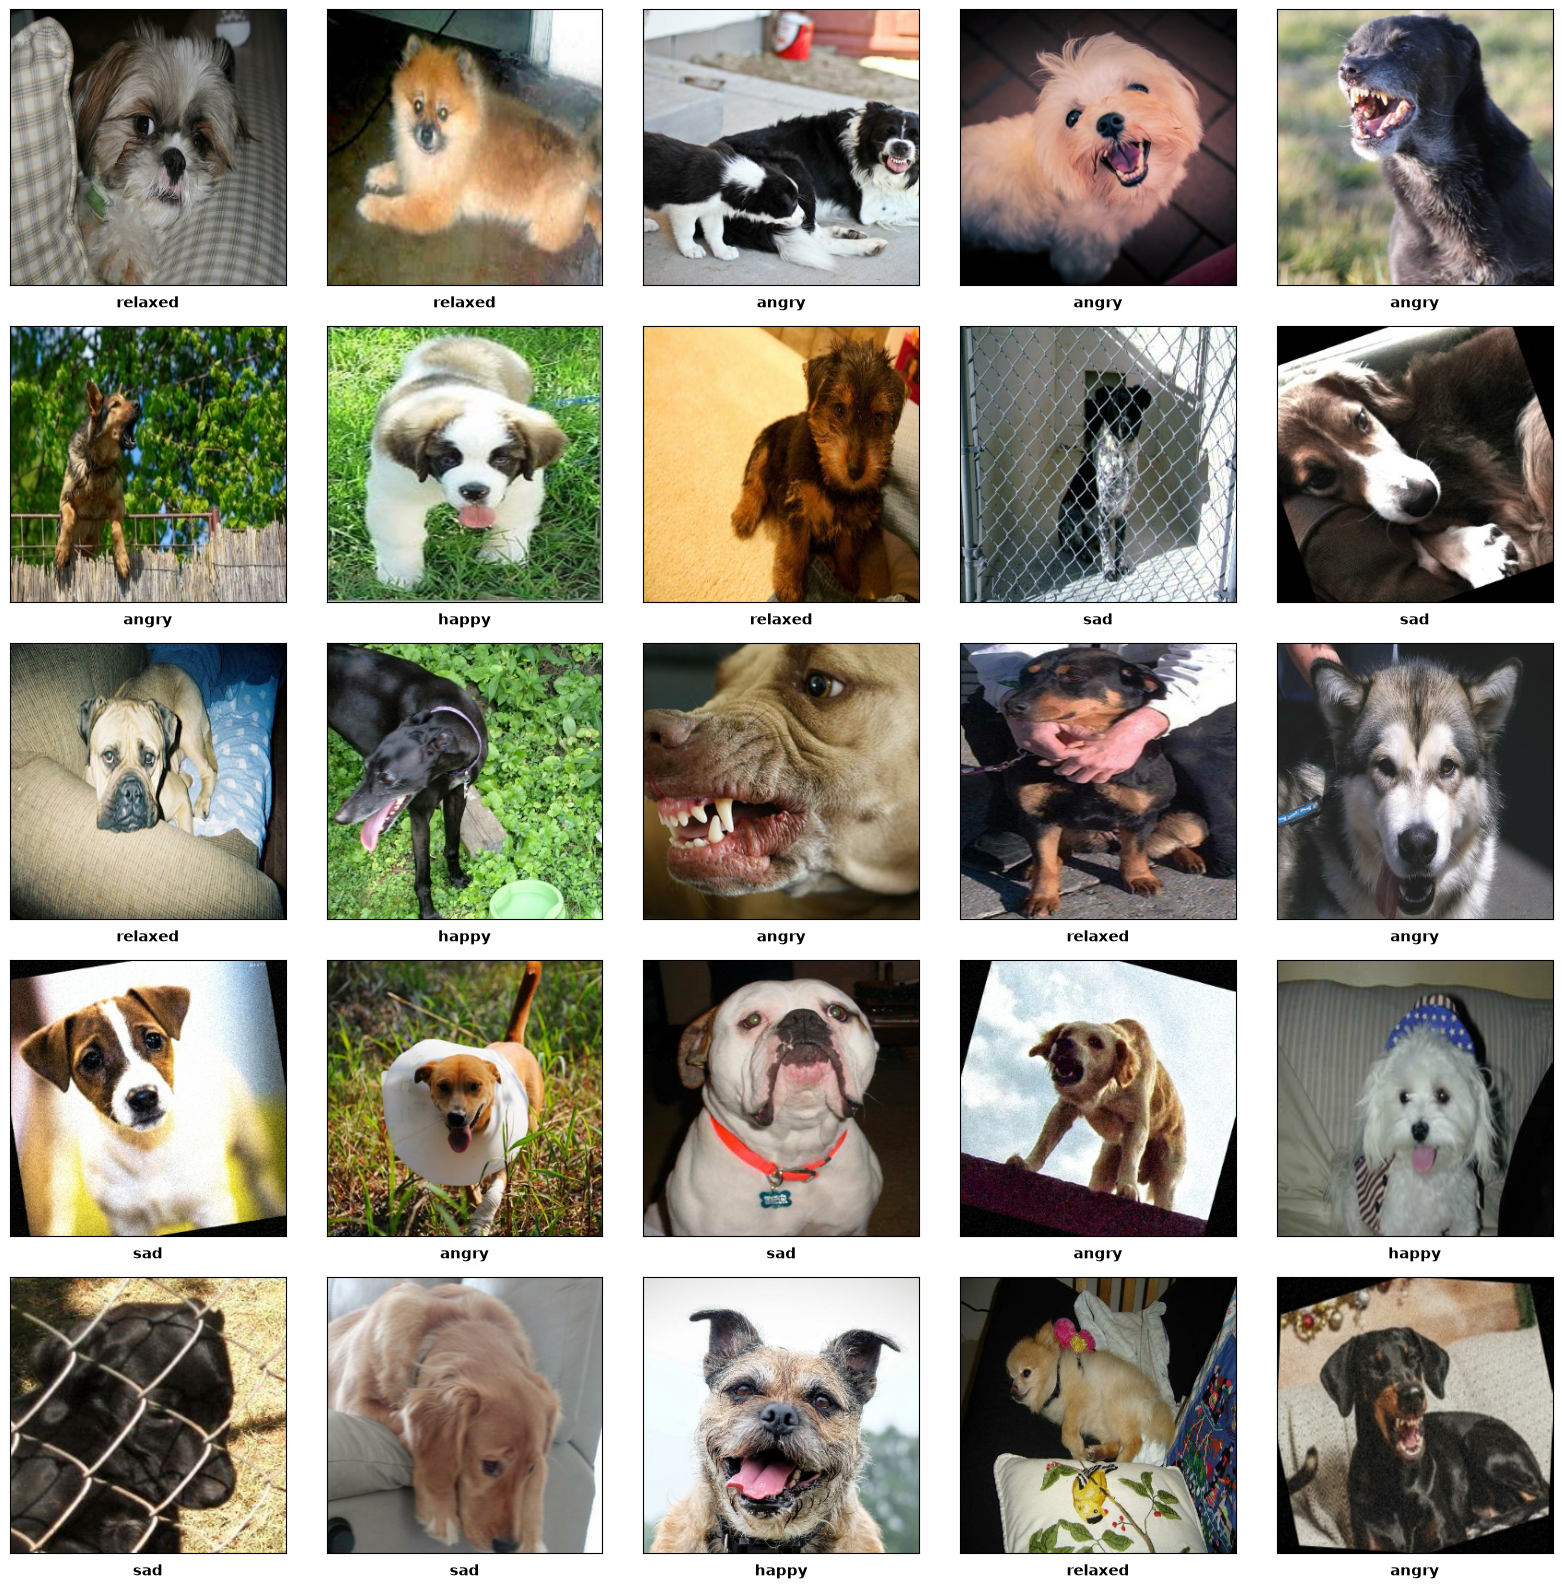

In [50]:
# Printeamos 25 imagenes de distintos baches para verificar que se ven.
images_list, labels_list = [], []

def denormalize(img):
    return (img + 1) / 2  # [-1,1] → [0,1]

for images_batch, labels_batch in train_ds.take(1):
    for img, label in zip(images_batch, labels_batch):
        images_list.append(img.numpy())
        labels_list.append(label.numpy())
        if len(images_list) == 25:
            break
    if len(images_list) == 25:
        break

# Visualizar (como arriba)
fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

for idx in range(25):
    image = denormalize(images_list[idx])
    label_name = class_names[labels_list[idx]]

    axes[idx].imshow(image)
    axes[idx].set_xlabel(label_name, fontsize=11, fontweight='bold', labelpad=8)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()

# Data Augmentation

En esta seccion hacemos vemos el data augmentation.

Respecto al data augmentation hay dos formas de hacer aumento de datos:

* Offline (en disco):  copias rotadas/espejadas, guardadas como archivos nuevos, y ahí sí el ds crece (pasaría de 2560 a 5120).
* Al vuelo (esta poronga? o es bueno?): las transformaciones se aplican en memoria, en el momento, sobre las mismas 2560 imágenes. No se guarda nada nuevo.

En cada época el modelo sigue viendo 2560 imágenes (80 batches de 32). Lo que cambia es que en cada pasada esas 2560 vienen con una transformación aleatoria distinta:

Época 1: ve 2560 versiones (cada foto con su flip/rotación/zoom al azar).

Época 2: ve otras 2560 versiones de las mismas fotos, pero con transformaciones diferentes.

O sea, el conteo por época no se mueve, pero a lo largo de, por ejemplo, 15 épocas, el modelo termina viendo muchas variantes de cada perro y nunca dos veces exactamente la misma imagen.

In [51]:
# esta va a ser una capa para hacer el data aug.
# El augmentation no suma imágenes al dataset

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

# **Sección 3: Crear modelo**

La idea es hacer dos cosas, ANTES de inception meter el data augmentation, y luego del inception meter el nuevo clasificador.

Inception originalmente es algo como esto:

```
Imagen
   ↓
InceptionV3
   ↓
GlobalAveragePooling
   ↓
Dense(1000)
   ↓
1000 clases ImageNet
```



In [52]:
# <-- Todo esto lo podemos sacar, con lo que comentamos afuera es suficiente.

base_model = keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)

print("Las capas del modelo base (las muestro de la ultima a la primera):")

print("Si no le ponemos el include_top en False, aparecen la densa:")
base_model = keras.applications.InceptionV3(
    include_top=True,
    weights="imagenet",
    input_shape=(299, 299, 3)
)

base_model = keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(299, 299, 3)
)



Las capas del modelo base (las muestro de la ultima a la primera):
Si no le ponemos el include_top en False, aparecen la densa:


Por el include_top=False queda la estructura:



```
Imagen
   ↓
InceptionV3
   ↓
falta el clasificador
```



De la docu de [keras](https://keras.io/guides/transfer_learning/):

Freezing layers: understanding the trainable attribute
Layers & models have three weight attributes:

weights is the list of all weights variables of the layer.

trainable_weights is the list of those that are meant to be updated (via gradient descent) to minimize the loss during training.

non_trainable_weights is the list of those that aren't meant to be trained. Typically they are updated by the model during the forward pass.

**Si hacemos a una capa entrenable, le podemos aplicar fine tuning.**

Si le hacemos:



```python
layer.trainable = False
```

la congelamos.



In [53]:
def create_inception_model(num_classes=4, augment=True):
    '''
    Esta es una funcion que creamos para crear modelos de inceptionV3. El
    argumento num_clases sirve para definir a cuantas clases va a clasificar
    el modelo y el argumento augment define si usa data augmentation o no.
    '''

    base_model = keras.applications.InceptionV3(
        include_top=False,
        weights="imagenet",
        input_shape=(299, 299, 3),
    )
    # Congelamos el backbone: usamos las features de ImageNet tal cual,
    # solo entrenamos la cabeza nueva.
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))

    # Data augmentation como primeras capas del modelo (se desactiva sola en inference)
    # <-- Si usamos esto entonces no tenemos que usar la seccion de Data Augmentation arriba
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)


    # training=False fuerza que las capas de BatchNorm del backbone
    # queden en modo inferencia aunque el modelo esté entrenando la cabeza.
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")
    return model

Veamos como funciona este preprocesado

Archivo: /home/bussa/.cache/kagglehub/datasets/danielshanbalico/dog-emotion/versions/1/Dog Emotion/relaxed/chz0sK5fRIXBkBo7x1nk6Kx1r8vBG5273.jpg
Original     -> min: 2.916140556335449 max: 255.0
Preprocesada -> min: -0.9771283268928528 max: 1.0


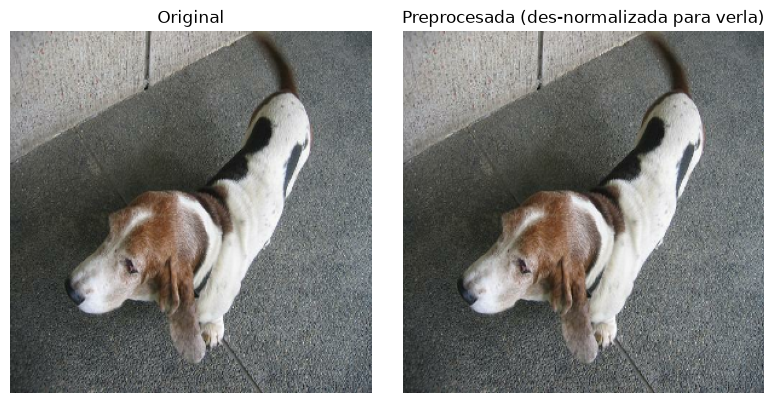

In [54]:
# Visualizamos el preprocesado de InceptionV3 sobre una FOTO ALEATORIA del dataset.
# (El pipeline ya entrega las imágenes preprocesadas en [-1, 1]; acá partimos de un
#  archivo crudo para ver el efecto del preprocesado a mano.)
import random

ruta = random.choice(paths_all)
raw = tf.io.read_file(ruta)
img = tf.io.decode_image(raw, channels=3, expand_animations=False)
img = tf.image.resize(img, IMG_SIZE)

img_pre = keras.applications.inception_v3.preprocess_input(tf.identity(img))

print("Archivo:", ruta)
print("Original     -> min:", float(tf.reduce_min(img)),     "max:", float(tf.reduce_max(img)))
print("Preprocesada -> min:", float(tf.reduce_min(img_pre)), "max:", float(tf.reduce_max(img_pre)))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img.numpy().astype("uint8"))
ax[0].set_title("Original"); ax[0].axis("off")
# La preprocesada está en [-1, 1]; para poder mostrarla la des-normalizamos a [0, 1].
ax[1].imshow((img_pre.numpy() + 1) / 2)
ax[1].set_title("Preprocesada (des-normalizada para verla)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

# **Auxiliar: Guardar y Cargar Modelos e Historias de Entrenamiento**

A continuación definimos funciones útiles para guardar el modelo y su historial de entrenamiento en disco (con soporte para descargarlo/cargarlo automáticamente si estás usando Google Colab).

In [55]:
import pickle
import os

def guardar_modelo_y_historial(model, history, base_name='modelo_inception_dogs'):
    """
    Guarda el modelo de Keras y su historial de entrenamiento en archivos.
    Soporta descarga automática si se ejecuta en Google Colab.
    """
    # Crear las carpetas si no existen (p. ej. al clonar el repo en limpio)
    os.makedirs("models", exist_ok=True)
    os.makedirs("histories", exist_ok=True)

    # Guardar el modelo. Usamos el nombre base tal como se solicita.
    model_path = f"models/{base_name}.keras"
    model.save(model_path)
    print(f"Modelo guardado exitosamente en: {model_path}")
    
    # Obtener el diccionario del historial y guardarlo con pickle
    history_dict = history.history if hasattr(history, 'history') else history
    history_path = f"histories/{base_name}_history.pkl"
    with open(history_path, 'wb') as f:
        pickle.dump(history_dict, f)
    print(f"Historial guardado exitosamente en: {history_path}")
    
    # Si estamos en Google Colab, descargamos los archivos automáticamente
    try:
        from google.colab import files
        # Si el modelo se guardó como carpeta (SavedModel sin extensión), se comprime para facilitar la descarga
        if os.path.isdir(model_path):
            import zipfile
            zip_path = f"{model_path}.zip"
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for root, dirs, files_in_dir in os.walk(model_path):
                    for file in files_in_dir:
                        zipf.write(os.path.join(root, file), 
                                   os.path.relpath(os.path.join(root, file), os.path.join(model_path, '..')))
            print(f"Modelo comprimido en {zip_path} para su descarga.")
            files.download(zip_path)
        else:
            files.download(model_path)
        files.download(history_path)
        print("Descargas iniciadas en Google Colab.")
    except ImportError:
        print("Entorno local detectado. Los archivos permanecen guardados en el disco local.")

In [56]:
from tensorflow.keras.models import load_model
import pickle
import os

def cargar_modelo_y_historial(base_name='modelo_inception_dogs'):
    """
    Permite subir archivos si se ejecuta en Google Colab y carga el modelo junto con su historial.
    """
    model_path = f"models/{base_name}.keras"
    history_path = f"histories/{base_name}_history.pkl"
    
    # Si estamos en Google Colab, solicita subir los archivos
    try:
        from google.colab import files
        print(f"Por favor, subí el modelo ({model_path}) y el historial ({history_path}):")
        uploaded = files.upload()
        # Si se subió un archivo zip (por haber guardado el modelo como carpeta)
        zip_path = f"{model_path}.zip"
        if zip_path in uploaded and not os.path.exists(model_path):
            import zipfile
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(".")
            print(f"Modelo descomprimido desde {zip_path}")
    except ImportError:
        print("Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.")
        
    # Cargar el modelo
    modelo_cargado = load_model(model_path)
    print(f"Modelo cargado exitosamente desde: {model_path}")
    
    # Cargar el historial
    with open(history_path, 'rb') as f:
        history_cargado = pickle.load(f)
    print(f"Historial cargado exitosamente desde: {history_path}")
    
    return modelo_cargado, history_cargado

# Ejemplo de uso (para cargar y hacer predicciones):
# modelo_recuperado, historial_recuperado = cargar_modelo_y_historial('modelo_inception_dogs')
# predicciones = modelo_recuperado.predict(test_ds)
# print("Predicciones realizadas de forma exitosa sobre test_ds.")

## **Sección 4: Modelo base para los experimentos**

#### El primer paso es encontrar cual es la mejor manera para obtener un **modelo base correcto**, a partir del cual podremos hacer experimentos y aplicar variaciones en su configuración, como puede ser dropout, data augmentation, etc. 

Este primer modelo base nos servirá para ir mutando, haciendo fine tuning y evaluando su performance.

Definimos `create_inception_model`, que arma InceptionV3 + cabeza nueva y permite:
- **descongelar las últimas N capas** del backbone (fine-tuning gradual),
- activar **data augmentation** y **dropout** (los usaremos en los datasets chicos).

> Esta versión corrige el bug del descongelado (`base_model.layers`, no `model.layers`) y
> redefine la función anterior al ejecutarse.

In [57]:
def create_inception_model(num_classes=4, augment=False,
                           cantidad_capas_descongeladas=0, dropout=0.0):
    '''
    InceptionV3 + cabeza nueva.
      - augment: capas de data augmentation (solo activas en training).
      - cantidad_capas_descongeladas: nº de capas FINALES del backbone que se entrenan.
      - dropout: tasa de dropout antes de la densa final (0 = sin dropout).
    '''
    base_model = keras.applications.InceptionV3(
        include_top=False, weights="imagenet", input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)

    x = base_model(x, training=False)          # BN del backbone en modo inferencia
    x = layers.GlobalAveragePooling2D()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")

    # Descongelar SOLO las últimas N capas (sin tocar BatchNorm):
    if cantidad_capas_descongeladas > 0:
        base_model.trainable = True
        for layer in base_model.layers:
            layer.trainable = False
        for layer in base_model.layers[-cantidad_capas_descongeladas:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
    return model

## Utilidades de evaluación

Funciones reutilizables para evaluar cualquier modelo:
- `predicciones`: corre el modelo sobre un dataset y devuelve etiquetas reales vs predichas.
- `plot_matriz_confusion`: dibuja la matriz de confusión (coloreada por proporción, anotada
  con conteos) e imprime el `classification_report` (precision / recall / f1 por clase).

In [58]:
from sklearn.metrics import confusion_matrix, classification_report

CLASES = ["angry", "happy", "relaxed", "sad"]   # orden de full_ds.class_names

def predicciones(model, ds):
    y_true = np.concatenate([y.numpy() for _, y in ds])
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)
    return y_true, y_pred

def plot_matriz_confusion(y_true, y_pred, titulo, clases=CLASES):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(clases)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                xticklabels=clases, yticklabels=clases)
    plt.xlabel("Predicho"); plt.ylabel("Real"); plt.title(titulo)
    plt.tight_layout(); plt.show()
    print(classification_report(y_true, y_pred, target_names=clases, digits=3))

In [ ]:
import time, glob, re
import pandas as pd

CONFIGS_DESCONGELADO = [0, 10, 30, 50, 100]   # InceptionV3 tiene 311 capas
EPOCHS_EXP1, PATIENCE_EXP1 = 40, 6

QUIERO_REENTRENAR = False

def _indices_existentes(base):
    """Devuelve los índices (ordenados) de los archivos base_<n>.keras ya guardados."""
    idxs = []
    for f in glob.glob(f"models/{base}_*.keras"):
        m = re.search(re.escape(base) + r"_(\d+)\.keras$", f)
        if m:
            idxs.append(int(m.group(1)))
    return sorted(idxs)


In [60]:

def entrenar_config(n_desc, train_ds, val_ds, *, augment=False, dropout=0.0, lr=None,
                    epochs=EPOCHS_EXP1, patience=PATIENCE_EXP1,
                    usar_early_stopping=False, verbose=1):
    """Entrena un modelo y devuelve (modelo, history_dict). No guarda nada."""
    keras.backend.clear_session()
    if lr is None:                       # LR alto para la cabeza, bajo para fine-tuning
        lr = 1e-3 if n_desc == 0 else 1e-4
    model = create_inception_model(num_classes=4, augment=augment,
                                   cantidad_capas_descongeladas=n_desc, dropout=dropout)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = []
    if usar_early_stopping:
        cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                patience=patience, restore_best_weights=True))
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=cb, verbose=verbose)
    return model, hist.history


In [61]:

def resultado(model, history, n_desc, test_ds, segundos=None):
    """Arma el dict de resultados (recalcula test/predicciones desde el modelo)."""
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = predicciones(model, test_ds)
    params = int(sum(tf.size(w).numpy() for w in model.trainable_weights))
    return {
        "n_descongeladas": n_desc, "params_entrenables": params,
        "best_val_acc": max(history["val_accuracy"]),
        "best_val_loss": min(history["val_loss"]),
        "epoca_min_val_loss": int(np.argmin(history["val_loss"])),
        "test_acc": float(test_acc), "test_loss": float(test_loss),
        "epocas_corridas": len(history["loss"]), "segundos": segundos,
        "history": history, "y_true": y_true, "y_pred": y_pred,
    }

## **Sección 4.1: Primer enfoque - descongelamiento por capas**

Entrenamos un modelo **independiente por cada cantidad de capas descongeladas** y vemos cómo
progresa la accuracy a medida que liberamos más del backbone. Sin data augmentation (con 4000
imágenes balanceadas no hace falta). Cada modelo se guarda (`.keras` + historial) y guardamos
también sus predicciones sobre *test* para la matriz de confusión.

In [62]:
resultados_exp1 = []
for n in CONFIGS_DESCONGELADO:
    base = f"exp1_desc{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR:
        ult = idxs[-1]
        print(f"\n[{n} capas] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} capas] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_exp1.append(r)
    del model
    keras.backend.clear_session()


[0 capas] Ya existe exp1_desc0_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc0_1.keras
Historial cargado exitosamente desde: histories/exp1_desc0_1_history.pkl

[10 capas] Ya existe exp1_desc10_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc10_1.keras
Historial cargado exitosamente desde: histories/exp1_desc10_1_history.pkl

[30 capas] Ya existe exp1_desc30_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_desc30_1.keras
Historial cargado exitosamente desde: histories/exp1_desc30_1_history.pkl

[50 capas] Ya existe exp1_desc50_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desd

### Exp 1 — Tabla resumen

Resultados por configuración: parámetros entrenables, mejor accuracy de validación, accuracy
en *test*, épocas efectivas (corta el EarlyStopping) y tiempo.

In [63]:
df_exp1 = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ("history", "y_true", "y_pred")}
                        for r in resultados_exp1])
df_exp1

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.69125,0.774400,27,0.66000,0.873728,40,None
1,10,8196,0.65750,0.879116,39,0.63875,0.915385,40,None
2,30,5160964,0.75250,0.668524,2,0.74875,1.215868,40,None
3,50,7176196,0.79625,0.585634,1,0.77250,1.338574,40,None
4,100,13623300,0.84625,0.509144,1,0.81625,1.176541,40,None


### Exp 1 — Gráficos

(a) Accuracy final (val y test) **vs** cantidad de capas descongeladas.
(b) Curvas de `val_accuracy` y `val_loss` por época, una por configuración.

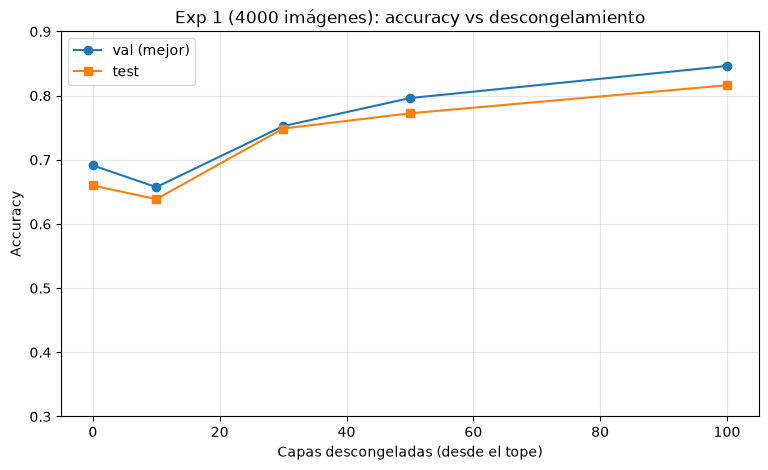

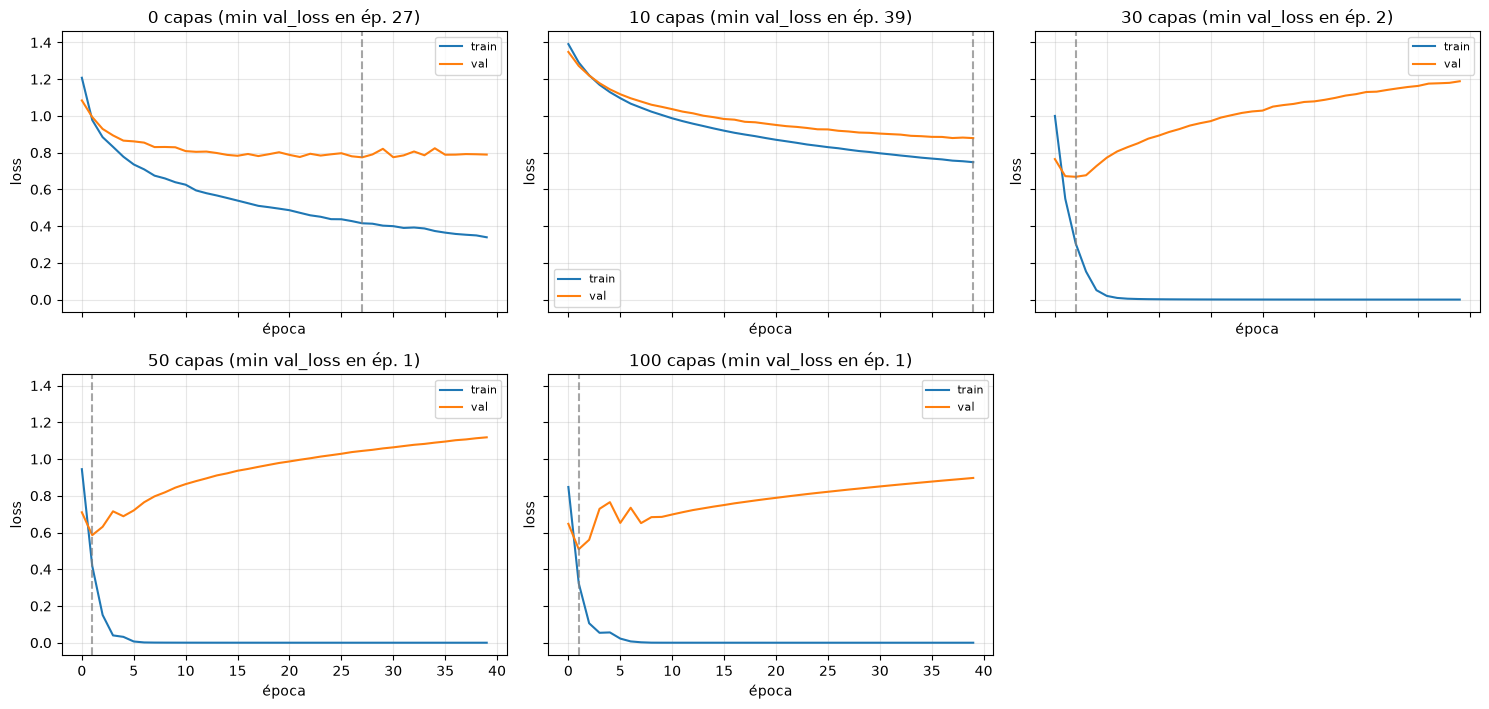

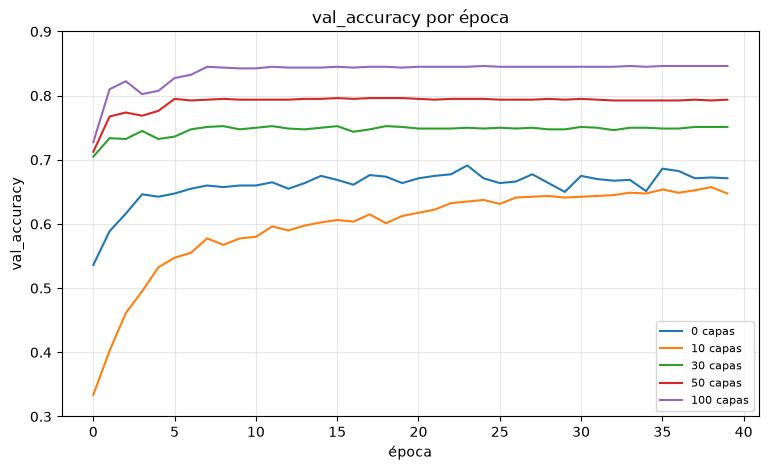

In [64]:
# (a) Accuracy final (val/test) vs capas descongeladas
plt.figure(figsize=(9, 5))
plt.plot(df_exp1["n_descongeladas"], df_exp1["best_val_acc"], "o-", label="val (mejor)")
plt.plot(df_exp1["n_descongeladas"], df_exp1["test_acc"], "s-", label="test")
plt.xlabel("Capas descongeladas (desde el tope)"); plt.ylabel("Accuracy")
plt.title("Exp 1 (4000 imágenes): accuracy vs descongelamiento"); plt.ylim(0.3, 0.9)
plt.grid(True, alpha=.3); plt.legend(); plt.show()

# (b) train vs val LOSS por configuración -> para ver CUÁNDO empieza el overfitting.
#     La línea punteada marca la época de menor val_loss (punto ideal de early stopping).
n = len(resultados_exp1)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows), squeeze=False, sharey=True, sharex=True)
for ax, r in zip(axes.flat, resultados_exp1):
    h = r["history"]
    ax.plot(h["loss"], label="train")
    ax.plot(h["val_loss"], label="val")
    mejor = int(np.argmin(h["val_loss"]))
    ax.axvline(mejor, ls="--", c="gray", alpha=.7)
    ax.set_title(f'{r["n_descongeladas"]} capas (min val_loss en ép. {mejor})')
    ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# (c) val_accuracy por época (todas las configuraciones juntas)
plt.figure(figsize=(9, 5))
for r in resultados_exp1:
    plt.plot(r["history"]["val_accuracy"], label=f'{r["n_descongeladas"]} capas')
plt.title("val_accuracy por época"); plt.xlabel("época"); plt.ylabel("val_accuracy"); plt.ylim(0.3, 0.9)
plt.grid(alpha=.3); plt.legend(fontsize=8); plt.show()

## Conclusiones 4.1

#### Notemos que descongelando 0 y 10 capas obtenemos los mismos resultados (los parámetros entrenables son 8196), esto se debe a que en InceptionV3 tiene entre sus últimas 10 capas sólo una entrenable, el resto como se ve en print superior no son entrenables.

## **Sección 4.2: Segundo enfoque - descongelamiento por bloques Inception**
A partir de ahora haremos descongelamiento por **bloques inception**, en particular con cero, uno y dos bloques, pues vimos también que a partir de las 30 capas descongeladas hay overfitting por lo que no creemos que valga la pena hacer un análisis más allá. Cada bloque inception refiere a una capa densa dentro del modelo.

Para calcular la lognitud de los bloques inception (cantidad de capas), usamos la siguiente funcion y modificamos `create_inception_model`:

In [66]:
QUIERO_REENTRENAR_BLOQUES = False

In [67]:
import re

def _inicio_ultimos_bloques(base_model, n_bloques):
    """Índice de capa desde donde descongelar para liberar los últimos n_bloques inception."""
    # mixed0..mixed10 son los puntos de concatenación de cada bloque (no matchea 'mixed9_0')
    mixed = [i for i, l in enumerate(base_model.layers) if re.fullmatch(r"mixed\d+", l.name)]
    if n_bloques <= 0:
        return len(base_model.layers)        # no descongela nada
    if n_bloques >= len(mixed):
        return 0                             # descongela todo el backbone
    # arrancamos justo DESPUÉS del mixed que queda n_bloques antes del final:
    # las convs de un bloque están entre su mixed anterior y su propio mixed.
    print(f'Cantidad de capas al descongelar {n_bloques}: {mixed[-(n_bloques + 1)] + 1}')
    return mixed[-(n_bloques + 1)] + 1


In [68]:
def create_inception_model_bloques(num_classes=4, augment=False,
                           n_bloques_descongelados=0, dropout=0.0):
    base_model = keras.applications.InceptionV3(
        include_top=False, weights="imagenet", input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")

    # Descongelar los últimos N bloques (sin tocar BatchNorm)
    if n_bloques_descongelados > 0:
        base_model.trainable = True
        inicio = _inicio_ultimos_bloques(base_model, n_bloques_descongelados)
        for layer in base_model.layers[:inicio]:
            layer.trainable = False
        for layer in base_model.layers[inicio:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
    return model

In [69]:

def entrenar_config_bloques(n_desc, train_ds, val_ds, *, augment=False, dropout=0.0, lr=None,
                    epochs=EPOCHS_EXP1, patience=PATIENCE_EXP1,
                    usar_early_stopping=False, verbose=1):
    """Entrena un modelo y devuelve (modelo, history_dict). No guarda nada."""
    keras.backend.clear_session()
    if lr is None:                       # LR alto para la cabeza, bajo para fine-tuning
        lr = 1e-3 if n_desc == 0 else 1e-4
    model = create_inception_model_bloques(num_classes=4, augment=augment,
                                   n_bloques_descongelados=n_desc, dropout=dropout)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = []
    if usar_early_stopping:
        cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                patience=patience, restore_best_weights=True))
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=cb, verbose=verbose)
    return model, hist.history


#### Este código nos ayuda a ver la relación capas-bloques y cuantos parámetros entrenaríamos a medida que descongelamos un bloque más.

In [70]:
base = keras.applications.InceptionV3(include_top=False, weights="imagenet",
                                      input_shape=(299, 299, 3))
for nb in [0, 1, 2, 3, 4, 7]:
    ini = _inicio_ultimos_bloques(base, nb)
    convs = sum(1 for l in base.layers[ini:] if isinstance(l, keras.layers.Conv2D))
    params = sum(int(tf.size(w)) for l in base.layers[ini:]
                 if not isinstance(l, keras.layers.BatchNormalization)
                 for w in l.trainable_variables) if nb > 0 else 0
    print(f"{nb:2} bloques -> arranca en capa {ini:3} | {convs:2} convs | ~{params:,} params")

 0 bloques -> arranca en capa 311 |  0 convs | ~0 params
Cantidad de capas al descongelar 1: 280
 1 bloques -> arranca en capa 280 |  9 convs | ~6,070,272 params
Cantidad de capas al descongelar 2: 249
 2 bloques -> arranca en capa 249 | 18 convs | ~11,108,352 params
Cantidad de capas al descongelar 3: 229
 3 bloques -> arranca en capa 229 | 24 convs | ~12,804,096 params
Cantidad de capas al descongelar 4: 197
 4 bloques -> arranca en capa 197 | 34 convs | ~14,942,208 params
Cantidad de capas al descongelar 7: 101
 7 bloques -> arranca en capa 101 | 64 convs | ~19,611,648 params


In [ ]:
resultados_exp1 = []
CONFIGS_BLOQUES = [0, 1, 2, 4]
for n in CONFIGS_BLOQUES:
    base = f"exp1_bloques_{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR_BLOQUES:
        ult = idxs[-1]
        print(f"\n[{n} bloques] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} bloques] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_exp1.append(r)
    del model
    keras.backend.clear_session()


[0 capas] Ya existe exp1_bloques_0_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_bloques_0_1.keras
Historial cargado exitosamente desde: histories/exp1_bloques_0_1_history.pkl

[1 capas] Ya existe exp1_bloques_1_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_bloques_1_1.keras
Historial cargado exitosamente desde: histories/exp1_bloques_1_1_history.pkl

[2 capas] Ya existe exp1_bloques_2_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_bloques_2_1.keras
Historial cargado exitosamente desde: histories/exp1_bloques_2_1_history.pkl

[4 capas] Ya existe exp1_bloques_4_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Carga

### Resultados del barrido por bloques

Graficamos el barrido por bloques con una función reutilizable (`graficar_barrido`) que también
usaremos para el barrido por convoluciones: tabla resumen, accuracy vs descongelamiento y las
curvas train/val de loss (con la época de menor `val_loss` marcada).

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.69000,0.764380,27,0.66250,0.870798,40,None
1,1,8196,0.64250,0.883284,39,0.63250,0.918301,40,None
2,2,8196,0.65125,0.867970,39,0.63375,0.913756,40,None
3,4,14960132,0.85750,0.434706,3,0.78125,0.985335,40,None


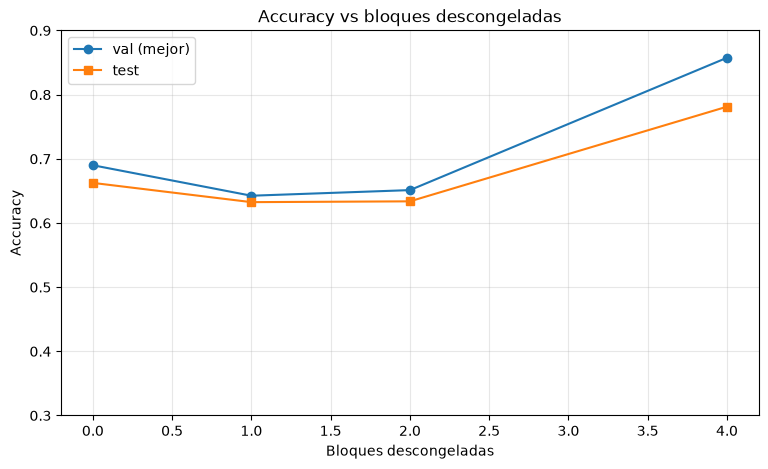

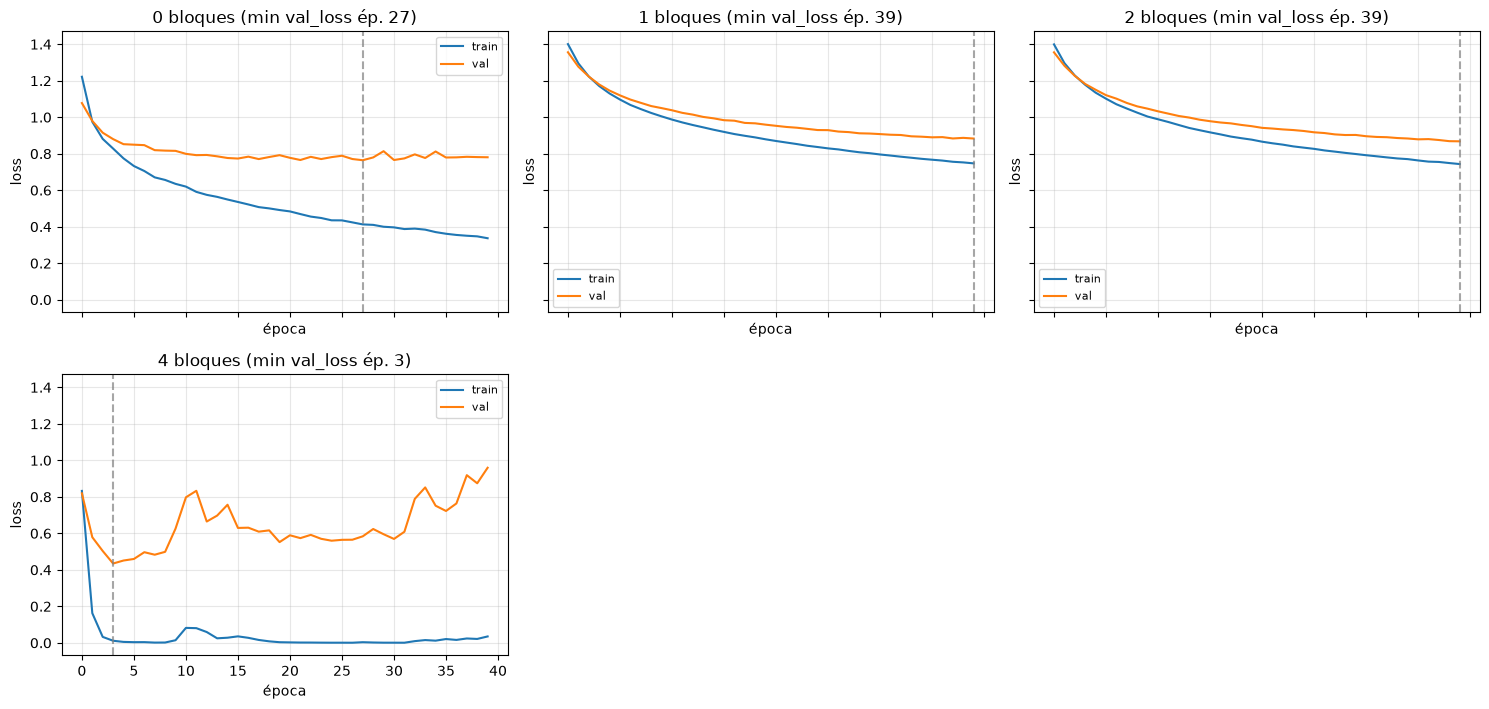

In [72]:
def graficar_barrido(resultados, etiqueta="capas"):
    """Tabla + accuracy vs descongelamiento + curvas de loss por configuración."""
    from IPython.display import display
    df = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ("history", "y_true", "y_pred")} for r in resultados])
    display(df)

    # (a) accuracy final vs cantidad descongelada
    plt.figure(figsize=(9, 5))
    plt.plot(df["n_descongeladas"], df["best_val_acc"], "o-", label="val (mejor)")
    plt.plot(df["n_descongeladas"], df["test_acc"], "s-", label="test")
    plt.xlabel(f"{etiqueta.capitalize()} descongeladas"); plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs {etiqueta} descongeladas"); plt.ylim(0.3, 0.9)
    plt.grid(True, alpha=.3); plt.legend(); plt.show()

    # (b) train vs val loss por configuración (línea = época de menor val_loss)
    n = len(resultados); cols = 3; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows), squeeze=False, sharey=True, sharex=True)
    for ax, r in zip(axes.flat, resultados):
        h = r["history"]
        ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="val")
        mejor = int(np.argmin(h["val_loss"])); ax.axvline(mejor, ls="--", c="gray", alpha=.7)
        ax.set_title(f'{r["n_descongeladas"]} {etiqueta} (min val_loss ép. {mejor})')
        ax.set_xlabel("época"); ax.set_ylabel("loss"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    for ax in axes.flat[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
    return df

df_bloques = graficar_barrido(resultados_exp1, "bloques")

## Conclusiones sección 4.2

Los bloques inception tienen tamaños desparejos (saltan de ~9 a ~18 a ~24 capas de convolución). Esto resulta en que los parámetros de entrenamiento rápidamente llevan al sobreajuste (con tan solo un bloque ya hay ~6M de parámetros).

## **Sección 4.3: Tercer y último enfoque - descongelamiento por capas *convolucionales***
Para un barrido más **uniforme y fino**, acá descongelamos por **cantidad de capas convolucionales**:
cada paso agrega exactamente una `Conv2D` entrenable. Es la unidad que mejor controla la
capacidad del modelo y evita puntos repetidos (como el 0 == 10 capas de antes).

In [82]:
# Poné en True para RE-ENTRENAR (crea el siguiente índice, no pisa); False = carga si existe.
QUIERO_REENTRENAR_CONVS = False

In [75]:
def _inicio_ultimas_convs(base_model, n_convs):
    """Índice desde donde descongelar para liberar las últimas n_convs capas Conv2D."""
    if n_convs <= 0:
        return len(base_model.layers)
    contador = 0
    for i in range(len(base_model.layers) - 1, -1, -1):   # de atrás hacia adelante
        if isinstance(base_model.layers[i], keras.layers.Conv2D):
            contador += 1
            if contador == n_convs:
                return i          # la conv n_convs-ésima desde el final
    return 0                      # n_convs >= total -> descongela todo

In [76]:
def create_inception_model(num_classes=4, augment=False, dropout=0.0,
                           n_convs_descongeladas=0,
                           n_bloques_descongelados=0,
                           cantidad_capas_descongeladas=0):
    """
    InceptionV3 + cabeza nueva. El descongelado se controla con UNO de estos argumentos
    (sin tocar las BatchNorm, que se dejan congeladas):
      - n_convs_descongeladas        -> últimas N capas Conv2D
      - n_bloques_descongelados      -> últimos N bloques inception (mixed)
      - cantidad_capas_descongeladas -> últimas N capas (compatibilidad con Exp 2)
    """
    base_model = keras.applications.InceptionV3(
        include_top=False, weights="imagenet", input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(299, 299, 3))
    x = inputs
    if augment:
        x = layers.RandomFlip("horizontal")(x)
        x = layers.RandomRotation(0.1)(x)
        x = layers.RandomZoom(0.1)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout and dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs, outputs, name="inceptionV3_dog_emotion")

    inicio = None
    if n_convs_descongeladas > 0:
        inicio = _inicio_ultimas_convs(base_model, n_convs_descongeladas)
    elif n_bloques_descongelados > 0:
        inicio = _inicio_ultimos_bloques(base_model, n_bloques_descongelados)
    elif cantidad_capas_descongeladas > 0:
        inicio = len(base_model.layers) - cantidad_capas_descongeladas

    if inicio is not None:
        base_model.trainable = True
        for layer in base_model.layers[:inicio]:
            layer.trainable = False
        for layer in base_model.layers[inicio:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True
    return model

In [77]:
def entrenar_config(n_desc, train_ds, val_ds, *, augment=False, dropout=0.0, lr=None,
                    epochs=EPOCHS_EXP1, patience=PATIENCE_EXP1,
                    usar_early_stopping=False, verbose=1):
    """Entrena descongelando n_desc CONVOLUCIONES. Devuelve (modelo, history_dict)."""
    keras.backend.clear_session()
    if lr is None:                       # LR alto para la cabeza, bajo para fine-tuning
        lr = 1e-3 if n_desc == 0 else 1e-4
    model = create_inception_model(num_classes=4, augment=augment,
                                   n_convs_descongeladas=n_desc, dropout=dropout)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = []
    if usar_early_stopping:
        cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                patience=patience, restore_best_weights=True))
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=cb, verbose=verbose)
    return model, hist.history

In [78]:
# Verificación: cuántos params libera cada cantidad de convoluciones (para elegir CONFIGS_CONVS)
_base_chk = keras.applications.InceptionV3(include_top=False, weights="imagenet",
                                           input_shape=(299, 299, 3))
total_convs = sum(1 for l in _base_chk.layers if isinstance(l, keras.layers.Conv2D))
print("Total Conv2D en InceptionV3:", total_convs)
for nc in [0, 2, 4, 8, 16, 32]:
    ini = _inicio_ultimas_convs(_base_chk, nc)
    params = (sum(int(tf.size(w)) for l in _base_chk.layers[ini:]
                  if not isinstance(l, keras.layers.BatchNormalization)
                  for w in l.trainable_variables)) if nc > 0 else 8196
    print(f"{nc:2} convs -> arranca en capa {ini:3} | ~{params:,} params entrenables")

Total Conv2D en InceptionV3: 94
 0 convs -> arranca en capa 311 | ~8,196 params entrenables
 2 convs -> arranca en capa 294 | ~1,048,576 params entrenables
 4 convs -> arranca en capa 291 | ~1,933,312 params entrenables
 8 convs -> arranca en capa 283 | ~5,152,768 params entrenables
16 convs -> arranca en capa 253 | ~10,043,392 params entrenables
32 convs -> arranca en capa 203 | ~14,536,704 params entrenables


In [83]:
resultados_convs = []
CONFIGS_CONVS = [0, 2, 4, 8, 16]   # nº de convoluciones finales a descongelar
for n in CONFIGS_CONVS:
    base = f"exp1_convs_{n}"
    idxs = _indices_existentes(base)

    if idxs and not QUIERO_REENTRENAR_CONVS:
        ult = idxs[-1]
        print(f"\n[{n} convs] Ya existe {base}_{ult}.keras -> CARGANDO (no entreno).")
        model, history = cargar_modelo_y_historial(f"{base}_{ult}")
        r = resultado(model, history, n, test_ds)
    else:
        nuevo = (idxs[-1] + 1) if idxs else 1
        accion = "RE-ENTRENANDO" if idxs else "ENTRENANDO"
        print(f"\n[{n} convs] {accion} -> se guardará como {base}_{nuevo}")
        t0 = time.time()
        model, history = entrenar_config(n, train_ds, val_ds, usar_early_stopping=False)
        seg = round(time.time() - t0, 1)
        guardar_modelo_y_historial(model, history, f"{base}_{nuevo}")
        r = resultado(model, history, n, test_ds, segundos=seg)

    resultados_convs.append(r)
    del model
    keras.backend.clear_session()


[0 convs] Ya existe exp1_convs_0_2.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_0_2.keras
Historial cargado exitosamente desde: histories/exp1_convs_0_2_history.pkl

[2 convs] Ya existe exp1_convs_2_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_2_1.keras
Historial cargado exitosamente desde: histories/exp1_convs_2_1_history.pkl

[4 convs] Ya existe exp1_convs_4_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directamente desde el directorio de trabajo.
Modelo cargado exitosamente desde: models/exp1_convs_4_1.keras
Historial cargado exitosamente desde: histories/exp1_convs_4_1_history.pkl

[8 convs] Ya existe exp1_convs_8_1.keras -> CARGANDO (no entreno).
Entorno local detectado. Cargando archivos directa

### Resultados del barrido por convoluciones

,n_descongeladas,params_entrenables,best_val_acc,best_val_loss,epoca_min_val_loss,test_acc,test_loss,epocas_corridas,segundos
0,0,8196,0.69375,0.766066,27,0.65875,0.865624,40,None
1,2,1058820,0.76125,0.597349,13,0.76000,0.734313,40,None
2,4,1943556,0.77375,0.590582,9,0.74000,0.768282,40,None
3,8,5163780,0.78375,0.603086,5,0.76250,0.893374,40,None
4,16,10057668,0.81625,0.512497,3,0.79500,0.903212,40,None


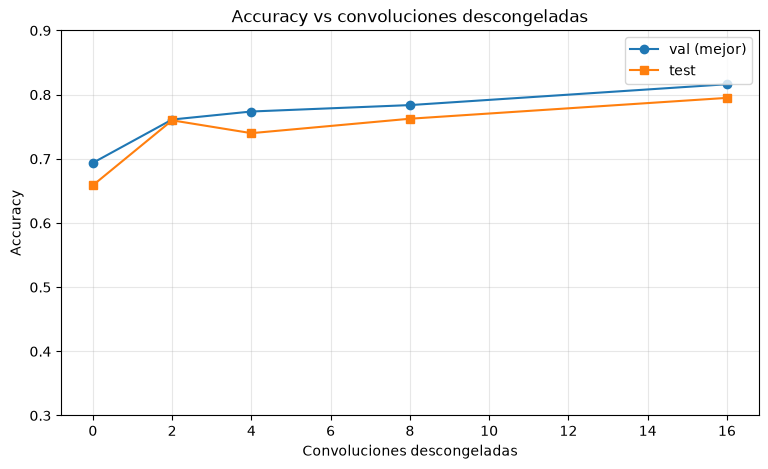

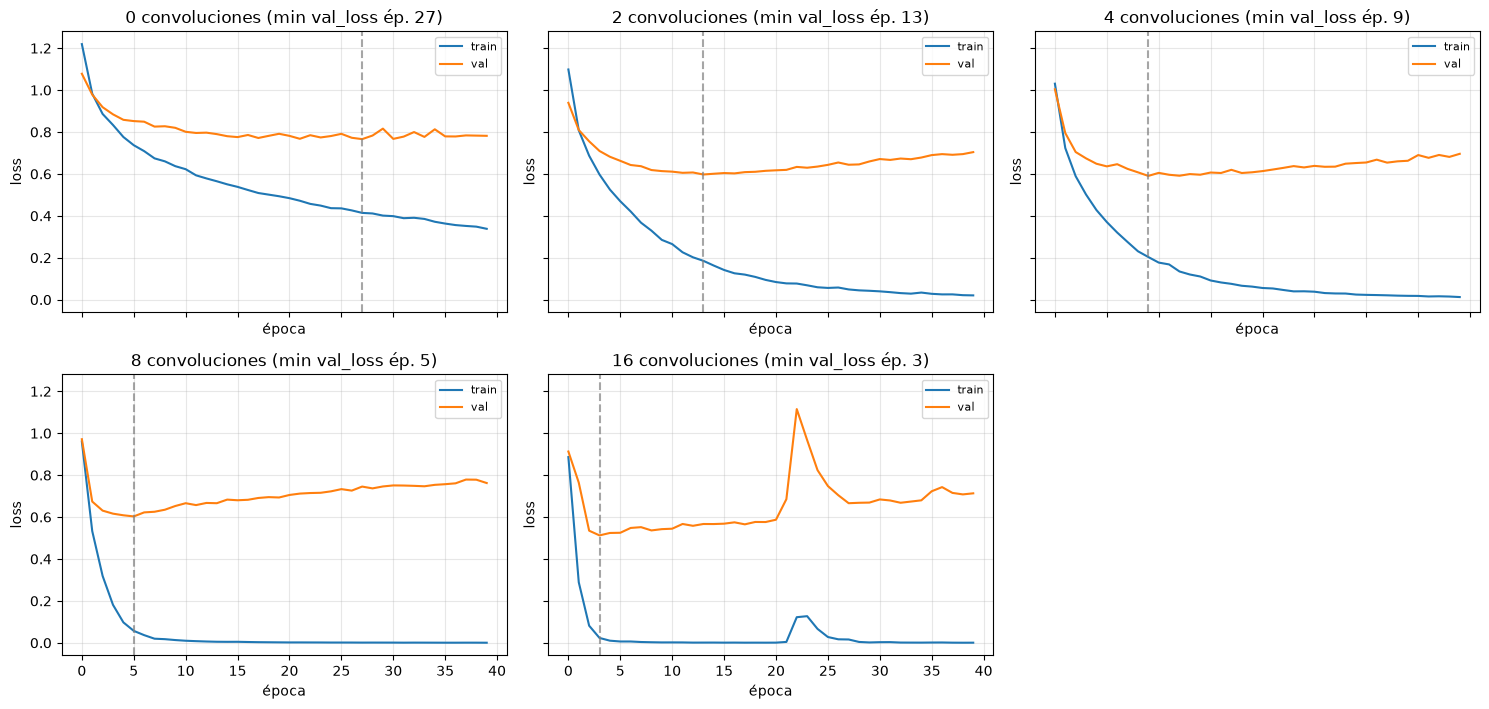

In [84]:
df_convs = graficar_barrido(resultados_convs, "convoluciones")

## Conclusiones sección 4.3

Vemos como los resultados hasta *n = 8* son relativamente inferiores en términos de accuracy a los obtenidos descongelando un bloque inception, lo que tiene sentido pues son significativamente (~1M menos) parámetros.  

Sin embargo, es una curva mucho más suave, que nos permite detectar mejor dónde empieza a aparecer el **sobreajuste**: la época de menor `val_loss` se corre de forma gradual (13 -> 9 -> 5 -> 3) a medida que liberamos más convoluciones, en lugar de caer de golpe a la época 1 como pasaba al descongelar por capas o por bloques.

Creemos que, usando técnicas como **data augmentation** y **dropout**, podemos subir estos valores sin que el sobreajuste se dispare.

**¿Por qué este enfoque es el mejor para nuestro modelo base?**

Usando el descongelamiento por capas convolucionales, cada paso agrega exactamente una `Conv2D` entrenable, por lo que los parámetros crecen de manera pareja (1.0M -> 1.9M -> 5.1M -> 10.0M) y no se repiten puntos (como el 0 == 10 del primer enfoque, ni los saltos desparejos de los bloques). 

Eso nos da una base correcta: podemos fijar una cantidad de convoluciones y variar una sola cosa por vez (dropout, data augmentation, tamaño del dataset) para medir su efecto real, que es justamente lo que haremos en el Experimento 2.

### Extra: Matriz de confusión por modelo

Para cada configuración, matriz de confusión sobre el set de *test* y reporte por clase.
Sirve para ver **qué emociones se confunden entre sí** (no solo la accuracy global).

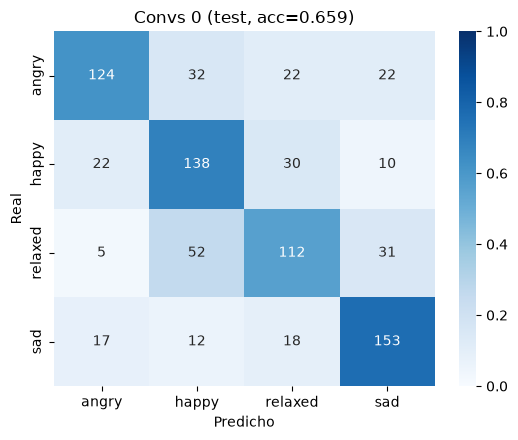

              precision    recall  f1-score   support

       angry      0.738     0.620     0.674       200
       happy      0.590     0.690     0.636       200
     relaxed      0.615     0.560     0.586       200
         sad      0.708     0.765     0.736       200

    accuracy                          0.659       800
   macro avg      0.663     0.659     0.658       800
weighted avg      0.663     0.659     0.658       800



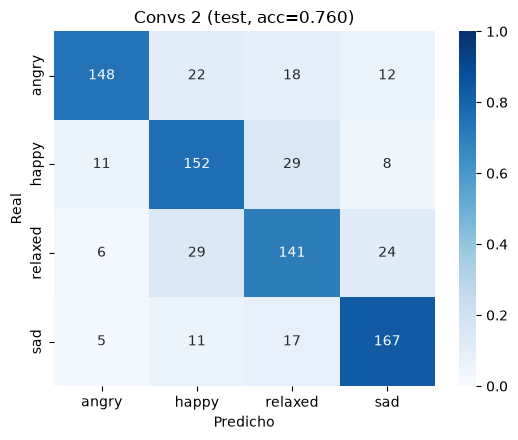

              precision    recall  f1-score   support

       angry      0.871     0.740     0.800       200
       happy      0.710     0.760     0.734       200
     relaxed      0.688     0.705     0.696       200
         sad      0.791     0.835     0.813       200

    accuracy                          0.760       800
   macro avg      0.765     0.760     0.761       800
weighted avg      0.765     0.760     0.761       800



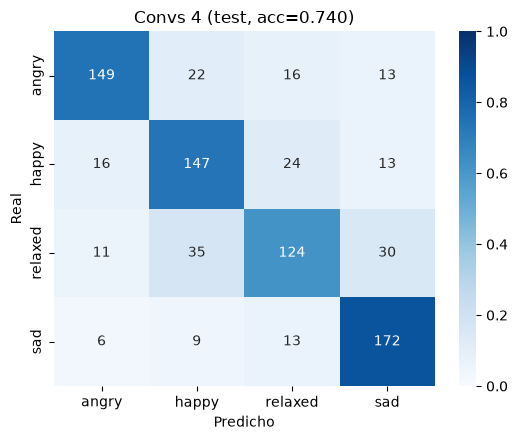

              precision    recall  f1-score   support

       angry      0.819     0.745     0.780       200
       happy      0.690     0.735     0.712       200
     relaxed      0.701     0.620     0.658       200
         sad      0.754     0.860     0.804       200

    accuracy                          0.740       800
   macro avg      0.741     0.740     0.738       800
weighted avg      0.741     0.740     0.738       800



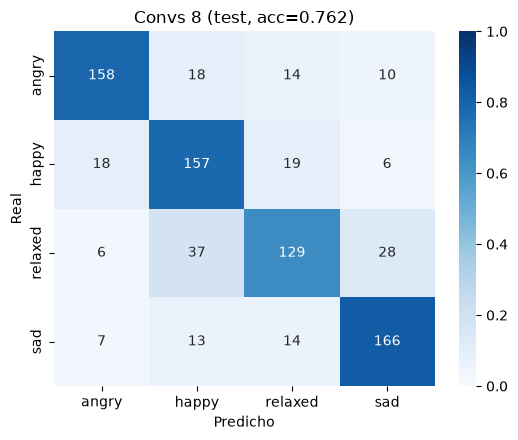

              precision    recall  f1-score   support

       angry      0.836     0.790     0.812       200
       happy      0.698     0.785     0.739       200
     relaxed      0.733     0.645     0.686       200
         sad      0.790     0.830     0.810       200

    accuracy                          0.762       800
   macro avg      0.764     0.763     0.762       800
weighted avg      0.764     0.762     0.762       800



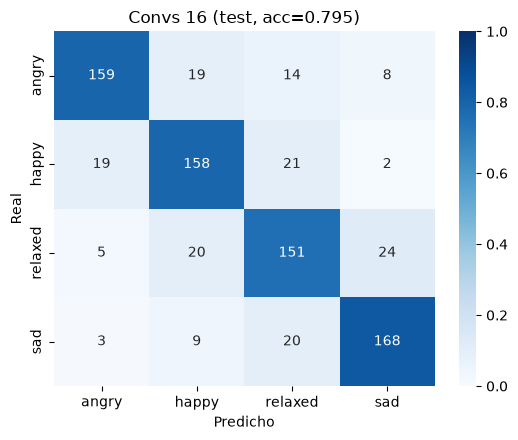

              precision    recall  f1-score   support

       angry      0.855     0.795     0.824       200
       happy      0.767     0.790     0.778       200
     relaxed      0.733     0.755     0.744       200
         sad      0.832     0.840     0.836       200

    accuracy                          0.795       800
   macro avg      0.797     0.795     0.795       800
weighted avg      0.797     0.795     0.795       800



In [85]:
# Matrices de confusión del barrido por convoluciones
for r in resultados_convs:
    plot_matriz_confusion(
        r["y_true"], r["y_pred"],
        f'Convs {r["n_descongeladas"]} (test, acc={r["test_acc"]:.3f})')

# **Sección 5: Utilizando el modelo base con distintas opciones**

A lo largo de la **Sección 4** buscamos la mejor forma de descongelar InceptionV3 y concluimos que el barrido por **capas convolucionales** es el más controlable. De ese barrido elegimos como **modelo base** el de **2 convoluciones descongeladas**, porque es el que mejor combina las dos cosas que nos importan:

- **Evita el sobreajuste:** su `val_loss` mínimo recién aparece en la época 13 (contra época 3 a 5 al descongelar más capas).
- **Buena precisión con pocos parámetros:** 0.760 de accuracy en test con solo ~1.06M de parámetros entrenables, prácticamente empatado con configuraciones de 5 a 10M.

Recordamos sus números del barrido de la sección 4.3:

| n convs | params | val_acc | época min val_loss |
|---|---|---|---|
| **2 (base)** | 1.06M | 0.761 | 13 |

Sobre esta base vamos a probar **distintas estrategias de regularización** (dropout, data augmentation y algo más de capacidad) y medir su efecto de forma robusta con **validación cruzada k-fold**, en lugar de un único split que es ruidoso.


### 5.1 Estrategias a evaluar

Partimos del modelo base (2 convoluciones, sin regularización) y combinamos tres ejes:

- **Capacidad** (capas convolucionales descongeladas): `n = 2` (base) y `n = 8` (más capacidad).
- **Dropout** antes de la capa densa final: `0.0`, `0.2` y `0.5`.
- **Data augmentation** (flip / rotación / zoom al vuelo): activado o no.

No probamos la grilla completa (sería 2 x 3 x 2 = 12 combinaciones) sino una **lista curada** que va sumando regularización de a poco, para aislar qué aporta cada técnica:

| # | Estrategia | n convs | dropout | augment |
|---|---|---|---|---|
| 1 | base (sin reg) | 2 | 0.0 | no |
| 2 | + dropout 0.2 | 2 | 0.2 | no |
| 3 | + dropout 0.5 | 2 | 0.5 | no |
| 4 | + augment | 2 | 0.0 | sí |
| 5 | + dropout 0.2 + augment | 2 | 0.2 | sí |
| 6 | más capacidad + reg | 8 | 0.2 | sí |
| 7 | más capacidad + reg fuerte | 8 | 0.5 | sí |



### 5.2 Evaluación con K-Fold Cross Validation

Con un único split, la accuracy depende mucho de qué imágenes cayeron en validación. Para una estimación más **robusta** usamos **StratifiedKFold** (mantiene el balance de clases en cada fold): entrenamos `k = 5` modelos por estrategia, cada uno validando en un fold distinto, y reportamos **media ± desvío** de la accuracy y de la loss.

Además juntamos las predicciones **out-of-fold** (la predicción de cada imagen cuando le tocó estar en validación) de los 5 folds en una única matriz de confusión por estrategia, que cubre las 4000 imágenes sin fuga de información.

Usamos **early stopping** (monitoreando `val_accuracy`, paciencia 6) para cortar cada fold cuando deja de mejorar, y cacheamos los resultados en disco para no reentrenar al re-ejecutar el notebook.


In [ ]:
# --- Utilidades de la Sección 5 (autocontenidas: no dependen de las celdas de Exp 2) ---
import os, time, pickle
from sklearn.model_selection import StratifiedKFold

def ds_desde_archivos(paths, labels, batch=BATCH, shuffle=False, seed=SEED):
    """tf.data desde una lista de archivos, con el preprocesado de InceptionV3."""
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=seed, reshuffle_each_iteration=True)
    def cargar(p, y):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)
        return img, y
    return ds.map(cargar, num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)


def kfold_estrategia(paths, labels, *, n_convs, dropout, augment,
                     k=5, lr=None, epochs=40, patience=6, batch=BATCH,
                     usar_early_stopping=True, verbose=0):
    """Corre k-fold estratificado para UNA estrategia y promedia las métricas.

    Devuelve un dict con media ± desvío de accuracy y loss entre folds, y las
    predicciones out-of-fold concatenadas (para la matriz de confusión).
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, losses, yt_all, yp_all = [], [], [], []
    for fold, (tr, va) in enumerate(skf.split(paths, labels), 1):
        keras.backend.clear_session()
        lr_f = (1e-3 if n_convs == 0 else 1e-4) if lr is None else lr
        train_ds_f = ds_desde_archivos(paths[tr], labels[tr], batch=batch, shuffle=True)
        val_ds_f   = ds_desde_archivos(paths[va], labels[va], batch=batch)
        model = create_inception_model(num_classes=4, augment=augment,
                                       n_convs_descongeladas=n_convs, dropout=dropout)
        model.compile(optimizer=keras.optimizers.Adam(lr_f),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = []
        if usar_early_stopping:
            cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                    patience=patience,
                                                    restore_best_weights=True))
        h = model.fit(train_ds_f, validation_data=val_ds_f,
                      epochs=epochs, callbacks=cb, verbose=verbose)
        accs.append(max(h.history["val_accuracy"]))
        losses.append(min(h.history["val_loss"]))
        yt, yp = predicciones(model, val_ds_f)
        yt_all.append(yt); yp_all.append(yp)
        print(f"    fold {fold}/{k}: val_acc={accs[-1]:.4f}  val_loss={losses[-1]:.4f}")
    return {
        "acc_media": float(np.mean(accs)),   "acc_std": float(np.std(accs)),
        "loss_media": float(np.mean(losses)), "loss_std": float(np.std(losses)),
        "accs": accs,
        "y_true": np.concatenate(yt_all), "y_pred": np.concatenate(yp_all),
    }


In [ ]:
# Poné en True para REENTRENAR; False = carga el .pkl si existe (no reentrena).
QUIERO_REENTRENAR_ESTRATEGIAS = False
RUTA_ESTRATEGIAS = "histories/resultados_estrategias.pkl"
K_FOLDS = 5

# --- Lista curada de estrategias ---------------------------------------------
# Cada elemento es una tupla (nombre_legible, hiperparámetros).
# El dict define el modelo: cuántas convoluciones descongelar (n_convs),
# cuánto dropout, y si activar data augmentation. Van sumando regularización
# de a poco para aislar qué aporta cada técnica.
ESTRATEGIAS = [
    ("base (n=2, sin reg)",         dict(n_convs=2, dropout=0.0, augment=False)),
    ("n=2 + dropout 0.2",           dict(n_convs=2, dropout=0.2, augment=False)),
    ("n=2 + dropout 0.5",           dict(n_convs=2, dropout=0.5, augment=False)),
    ("n=2 + augment",               dict(n_convs=2, dropout=0.0, augment=True)),
    ("n=2 + dropout 0.2 + augment", dict(n_convs=2, dropout=0.2, augment=True)),
    ("n=8 + dropout 0.2 + augment", dict(n_convs=8, dropout=0.2, augment=True)),
    ("n=8 + dropout 0.5 + augment", dict(n_convs=8, dropout=0.5, augment=True)),
]

if os.path.exists(RUTA_ESTRATEGIAS) and not QUIERO_REENTRENAR_ESTRATEGIAS:
    with open(RUTA_ESTRATEGIAS, "rb") as f:
        resultados_estrategias = pickle.load(f)
    print(f"Cargado {RUTA_ESTRATEGIAS} ({len(resultados_estrategias)} estrategias) -> no reentreno.")
else:
    #  correr el barrido completo.
    resultados_estrategias = []                      # acá se acumulan los resultados

    # Recorremos cada estrategia de la lista.
    for nombre, cfg in ESTRATEGIAS:

        print(f"\n== {nombre} | {K_FOLDS}-fold sobre {len(paths_all)} imágenes ==")
        t0 = time.time()

        #entrena K_FOLDS modelos (uno por fold) y promedia.
        # **cfg desempaqueta el dict -> n_convs=..., dropout=..., augment=...
        # Devuelve un dict con acc_media, acc_std, loss_media, loss_std y las
        # predicciones out-of-fold (y_true, y_pred).
        m = kfold_estrategia(paths_all, labels_all, k=K_FOLDS, **cfg)

        # Le agregamos al resultado: el nombre, cuánto tardó, y los propios
        # hiperparámetros (para tenerlos como columnas en la tabla final).
        m.update({"estrategia": nombre, "segundos": round(time.time() - t0, 1), **cfg})

        print(f"   => acc = {m['acc_media']:.4f} ± {m['acc_std']:.4f} | "
              f"loss = {m['loss_media']:.4f} ± {m['loss_std']:.4f}")

        resultados_estrategias.append(m)

    os.makedirs("histories", exist_ok=True)
    with open(RUTA_ESTRATEGIAS, "wb") as f:
        pickle.dump(resultados_estrategias, f)
    print(f"\nGuardado en {RUTA_ESTRATEGIAS}")

# --- Tabla resumen -----------------------------------------------------------
# Pasamos la lista de dicts a un DataFrame, descartando los campos pesados o
# no tabulares (arrays de predicciones y la lista de accuracies por fold).
df_estrategias = pd.DataFrame([{k: v for k, v in r.items()
                                if k not in ("y_true", "y_pred", "accs")}
                               for r in resultados_estrategias])

# Ordenamos de mayor a menor accuracy media (la mejor estrategia queda arriba)
# y renumeramos las filas desde 0.
df_estrategias = (df_estrategias
                  .sort_values("acc_media", ascending=False)
                  .reset_index(drop=True))

 # última línea suelta: Jupyter la muestra como tabla
df_estrategias


### 5.3 Resultados

Comparamos las estrategias por su accuracy media entre folds (con el desvío como barra de error) y mostramos la matriz de confusión out-of-fold de la mejor, junto con su reporte de precision / recall / f1 por clase.


In [ ]:
# Accuracy media ± desvío por estrategia (de peor a mejor)
orden = df_estrategias.sort_values("acc_media")
plt.figure(figsize=(9, 5))
plt.barh(orden["estrategia"], orden["acc_media"],
         xerr=orden["acc_std"], capsize=4, color="#4C72B0")
plt.xlabel(f"Accuracy media ({K_FOLDS}-fold)")
plt.xlim(0.5, 0.9)
plt.title("Sección 5: accuracy por estrategia de regularización")
plt.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()


In [ ]:
# Matriz de confusión out-of-fold de la MEJOR estrategia (+ classification_report)
mejor = max(resultados_estrategias, key=lambda r: r["acc_media"])
print(f"Mejor estrategia: {mejor['estrategia']}  "
      f"(acc {mejor['acc_media']:.3f} ± {mejor['acc_std']:.3f})\n")
plot_matriz_confusion(mejor["y_true"], mejor["y_pred"],
                      f"Mejor estrategia: {mejor['estrategia']} (out-of-fold)")


## Conclusiones sección 5

> A completar una vez ejecutado el barrido. Puntos a mirar:
> - ¿El **dropout** (0.2 / 0.5) mejora la accuracy media o solo reduce la varianza entre folds?
> - ¿El **data augmentation** aporta sobre las 4000 imágenes, o recién se nota con datasets chicos (como en el Experimento 2)?
> - ¿Conviene **más capacidad** (n=8) con regularización, o el modelo base (n=2) ya alcanza?
> - En la matriz de confusión: ¿qué clases se siguen confundiendo (p. ej. *sad* vs *relaxed*)?



_Lo que sigue son las celdas originales del **Experimento 2 (datasets reducidos)**. Algunas utilidades (`ds_desde_archivos`, `kfold_experimento`) se redefinen acá, pero son equivalentes a las que usamos arriba._


## Experimento 2 — Datasets reducidos

Si con pocas capas ya clasifica muy bien, el problema es "fácil" con 4000 imágenes. Repetimos
el experimento con **datasets más chicos** (1000, 100, …), donde sí valen las técnicas de
regularización. Primero, utilidades para listar archivos, **submuestrear de forma estratificada**
(mantiene el balance de clases) y armar `tf.data` desde una lista de archivos.

In [86]:
import pathlib
from sklearn.model_selection import train_test_split, StratifiedKFold

def listar_archivos(data_dir, clases=CLASES):
    paths, labels = [], []
    for idx, cls in enumerate(clases):
        for p in sorted(pathlib.Path(data_dir, cls).glob("*")):
            if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                paths.append(str(p)); labels.append(idx)
    return np.array(paths), np.array(labels)

paths_all, labels_all = listar_archivos(data_dir)
print("Total:", len(paths_all), "| por clase:", np.bincount(labels_all))

def submuestrear(paths, labels, n_total, seed=SEED):
    if n_total >= len(paths):
        return paths, labels
    p, _, y, _ = train_test_split(paths, labels, train_size=n_total,
                                  stratify=labels, random_state=seed)
    return p, y

def ds_desde_archivos(paths, labels, batch=BATCH, shuffle=False, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=seed, reshuffle_each_iteration=True)
    def cargar(p, y):
        img = tf.io.read_file(p)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = preprocess_input(img)         # mismo preprocesado que el pipeline original
        return img, y
    return ds.map(cargar, num_parallel_calls=AUTOTUNE).batch(batch).prefetch(AUTOTUNE)

Total: 4000 | por clase: [1000 1000 1000 1000]


### Exp 2 — K-Fold Cross Validation

Con datos escasos, un solo split es ruidoso. Usamos **StratifiedKFold**: entrenamos `k` modelos,
cada uno validando en un fold distinto, y reportamos **media ± desvío** de la accuracy. Activamos
**data augmentation** y **dropout** (donde realmente aportan). Además juntamos las predicciones
*out-of-fold* de todos los folds para una única matriz de confusión por configuración.

In [87]:
def kfold_experimento(paths, labels, n_desc, *, k=5, augment=True, dropout=0.4,
                      lr=None, epochs=40, patience=6, batch=BATCH,
                      usar_early_stopping=True, verbose=0):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs, yt_all, yp_all = [], [], []
    for fold, (tr, va) in enumerate(skf.split(paths, labels), 1):
        keras.backend.clear_session()
        lr_f = (1e-3 if n_desc == 0 else 1e-4) if lr is None else lr
        train_ds_f = ds_desde_archivos(paths[tr], labels[tr], batch=batch, shuffle=True)
        val_ds_f   = ds_desde_archivos(paths[va], labels[va], batch=batch)

        # Descongelamos por CONVOLUCIONES (mismo criterio que el barrido por convs de Exp 1)
        model = create_inception_model(num_classes=4, augment=augment,
                                       n_convs_descongeladas=n_desc, dropout=dropout)
        model.compile(optimizer=keras.optimizers.Adam(lr_f),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        cb = []
        if usar_early_stopping:
            cb.append(keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                    patience=patience, restore_best_weights=True))
        hist = model.fit(train_ds_f, validation_data=val_ds_f,
                         epochs=epochs, callbacks=cb, verbose=verbose)

        yt, yp = predicciones(model, val_ds_f)         # predicciones out-of-fold
        yt_all.append(yt); yp_all.append(yp)
        best = max(hist.history["val_accuracy"]); accs.append(best)
        print(f"  fold {fold}/{k}: val_acc = {best:.4f}")
    return (float(np.mean(accs)), float(np.std(accs)), accs,
            np.concatenate(yt_all), np.concatenate(yp_all))

### Exp 2 — Barrido tamaño × descongelamiento

Para cada **tamaño de dataset** y cada **cantidad de capas descongeladas**, corremos k-fold y
guardamos la accuracy media y las predicciones out-of-fold.

> ⚠️ Compute: `len(TAMANOS) × len(CONFIGS) × K` entrenamientos (acá 2×3×5 = 30). Con datasets
> chicos son rápidos; subí los valores con criterio.

In [ ]:
TAMANOS            = [1000, 100]
CONFIGS_CONVS_EXP2 = [0, 4, 8]      # nº de convoluciones a descongelar
K = 5

# Dos variantes: primero SIN regularización (baseline) y después CON (dropout + augmentation),
# para ver cuánto ayudan cuando hay pocos datos.
VARIANTES = [
    ("sin reg", dict(augment=False, dropout=0.0)),
    ("con reg", dict(augment=True,  dropout=0.4)),
]
resultados_exp2 = []
for etiqueta, cfg in VARIANTES:
    for n_total in TAMANOS:
        p_sub, y_sub = submuestrear(paths_all, labels_all, n_total)
        for n_desc in CONFIGS_CONVS_EXP2:
            print(f"\n== [{etiqueta}] {len(p_sub)} imgs | {n_desc} convs | {K}-fold ==")
            mean, std, accs, yt, yp = kfold_experimento(p_sub, y_sub, n_desc, k=K, **cfg)
            print(f"   => acc media = {mean:.4f} ± {std:.4f}")
            resultados_exp2.append({"regularizacion": etiqueta, "n_datos": len(p_sub),
                                    "n_descongeladas": n_desc, "acc_media": mean,
                                    "acc_std": std, "y_true": yt, "y_pred": yp})

df_exp2 = pd.DataFrame([{k: v for k, v in r.items() if k not in ("y_true", "y_pred")}
                        for r in resultados_exp2])
df_exp2


== [sin reg] 1000 imgs | 0 convs | 5-fold ==


/home/bussa/venvs/tp-final/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1782687374.896531   71047 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782687377.941984   46289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_786869__.211
W0000 00:00:1782687386.088782   71110 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune

  fold 1/5: val_acc = 0.6000


W0000 00:00:1782687473.081391   72711 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782687475.163265   46291 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_817667__.211
W0000 00:00:1782687482.145436   72762 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1782687504.982393   72711 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exce

  fold 2/5: val_acc = 0.6200


W0000 00:00:1782687580.461138   73486 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782687583.373023   46289 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_846485__.211
W0000 00:00:1782687589.367607   73537 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109120 bytes after encountering the first element of size 67109120 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


### Exp 2 — Accuracy vs descongelamiento, por tamaño de dataset

Una curva por tamaño de dataset, con barras de error (desvío entre folds). Muestra cómo el
beneficio de descongelar más capas **cambia según cuántos datos tengamos**.

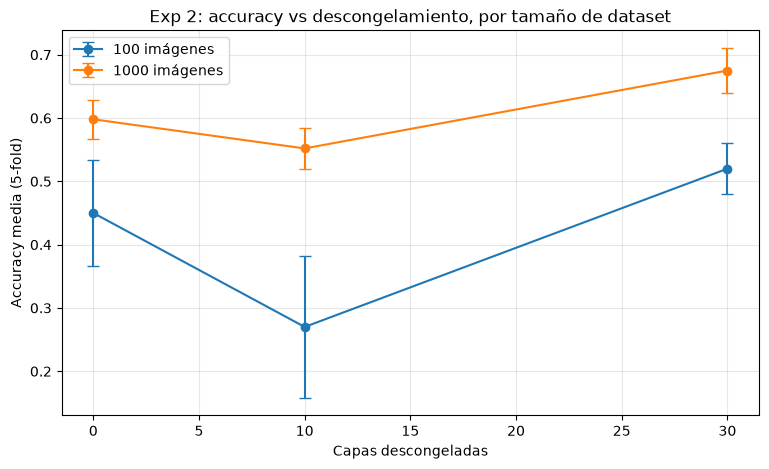

In [ ]:
# Comparación SIN vs CON regularización, un panel por tamaño de dataset
tamanos = sorted(df_exp2["n_datos"].unique())
fig, axes = plt.subplots(1, len(tamanos), figsize=(6 * len(tamanos), 5), squeeze=False, sharey=True)
for ax, n_total in zip(axes.flat, tamanos):
    for etiqueta in df_exp2["regularizacion"].unique():
        sub = df_exp2[(df_exp2["n_datos"] == n_total) &
                      (df_exp2["regularizacion"] == etiqueta)].sort_values("n_descongeladas")
        ax.errorbar(sub["n_descongeladas"], sub["acc_media"], yerr=sub["acc_std"],
                    fmt="o-", capsize=4, label=etiqueta)
    ax.set_title(f"{n_total} imágenes")
    ax.set_xlabel("Convoluciones descongeladas")
    ax.set_ylabel(f"Accuracy media ({K}-fold)")
    ax.set_ylim(0.3, 0.9); ax.grid(alpha=.3); ax.legend()
plt.suptitle("Exp 2: efecto de la regularización (dropout + augmentation) por tamaño de dataset")
plt.tight_layout(); plt.show()

### Exp 2 — Matriz de confusión por configuración

Matriz de confusión **agregada out-of-fold** (todas las predicciones de validación de los k
folds juntas) para cada combinación tamaño / descongelamiento.

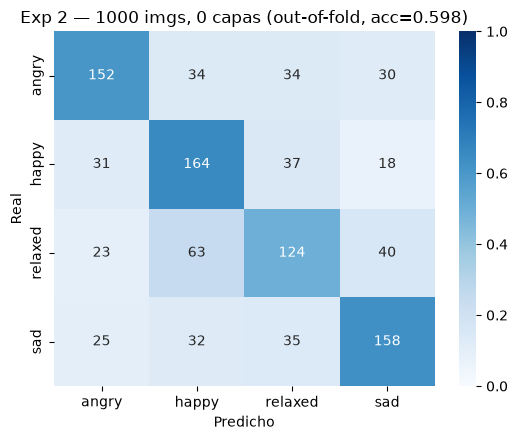

              precision    recall  f1-score   support

       angry      0.658     0.608     0.632       250
       happy      0.560     0.656     0.604       250
     relaxed      0.539     0.496     0.517       250
         sad      0.642     0.632     0.637       250

    accuracy                          0.598      1000
   macro avg      0.600     0.598     0.597      1000
weighted avg      0.600     0.598     0.597      1000



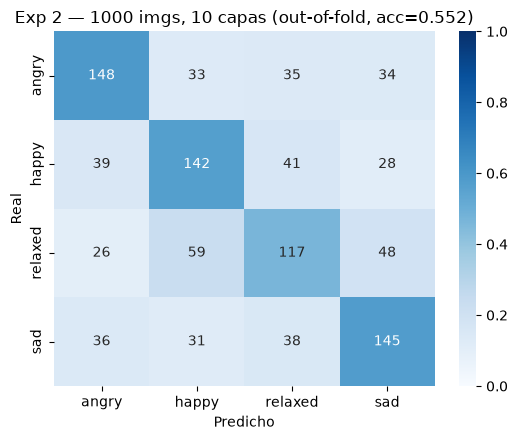

              precision    recall  f1-score   support

       angry      0.594     0.592     0.593       250
       happy      0.536     0.568     0.551       250
     relaxed      0.506     0.468     0.486       250
         sad      0.569     0.580     0.574       250

    accuracy                          0.552      1000
   macro avg      0.551     0.552     0.551      1000
weighted avg      0.551     0.552     0.551      1000



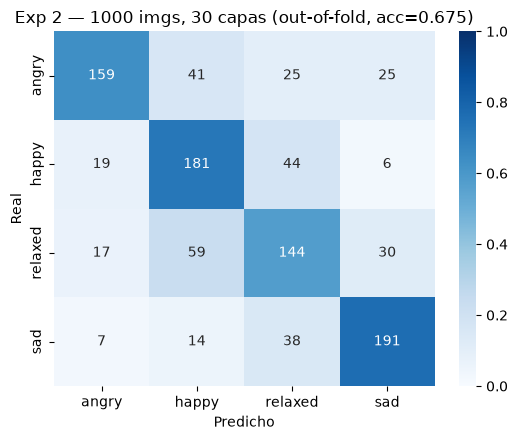

              precision    recall  f1-score   support

       angry      0.787     0.636     0.704       250
       happy      0.614     0.724     0.664       250
     relaxed      0.574     0.576     0.575       250
         sad      0.758     0.764     0.761       250

    accuracy                          0.675      1000
   macro avg      0.683     0.675     0.676      1000
weighted avg      0.683     0.675     0.676      1000



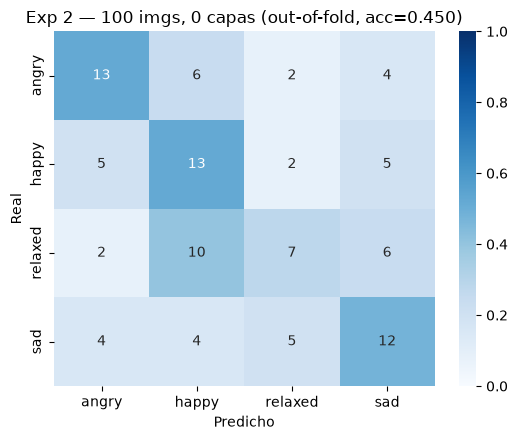

              precision    recall  f1-score   support

       angry      0.542     0.520     0.531        25
       happy      0.394     0.520     0.448        25
     relaxed      0.438     0.280     0.341        25
         sad      0.444     0.480     0.462        25

    accuracy                          0.450       100
   macro avg      0.454     0.450     0.445       100
weighted avg      0.454     0.450     0.445       100



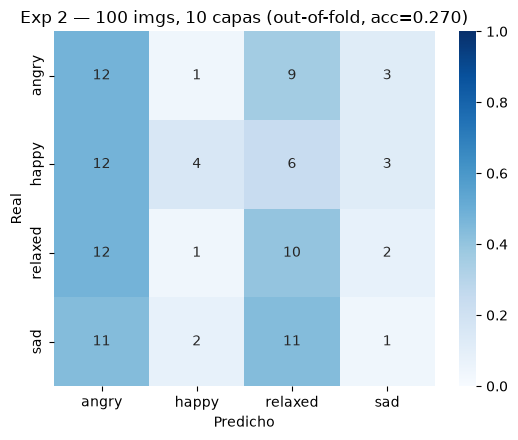

              precision    recall  f1-score   support

       angry      0.255     0.480     0.333        25
       happy      0.500     0.160     0.242        25
     relaxed      0.278     0.400     0.328        25
         sad      0.111     0.040     0.059        25

    accuracy                          0.270       100
   macro avg      0.286     0.270     0.241       100
weighted avg      0.286     0.270     0.241       100



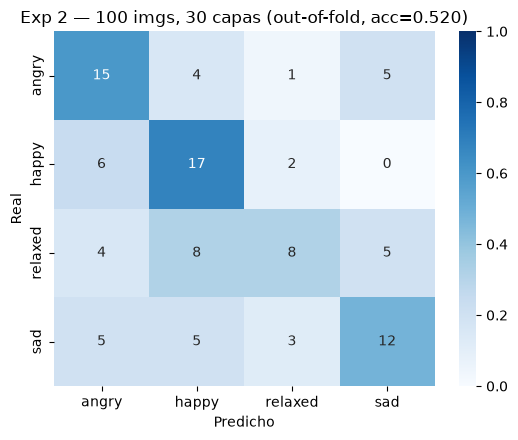

              precision    recall  f1-score   support

       angry      0.500     0.600     0.545        25
       happy      0.500     0.680     0.576        25
     relaxed      0.571     0.320     0.410        25
         sad      0.545     0.480     0.511        25

    accuracy                          0.520       100
   macro avg      0.529     0.520     0.511       100
weighted avg      0.529     0.520     0.511       100



In [ ]:
for r in resultados_exp2:
    plot_matriz_confusion(
        r["y_true"], r["y_pred"],
        f'Exp 2 [{r["regularizacion"]}] — {r["n_datos"]} imgs, {r["n_descongeladas"]} convs '
        f'(out-of-fold, acc={r["acc_media"]:.3f})')